In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [3]:
hourly_df = pd.read_csv(
    "../data/processed/hourly_energy.csv"
)

hourly_df.head()

,city,meter,x_Timestamp,t_kWh
0,Bareilly,BR02,2019-07-10 00:00:00,0.405
1,Bareilly,BR02,2019-07-10 01:00:00,0.446
2,Bareilly,BR02,2019-07-10 02:00:00,0.447
3,Bareilly,BR02,2019-07-10 03:00:00,0.450
4,Bareilly,BR02,2019-07-10 04:00:00,0.454


In [4]:
meter_df = hourly_df[
    hourly_df["meter"] == "BR02"
].copy()

meter_df.head()

,city,meter,x_Timestamp,t_kWh
0,Bareilly,BR02,2019-07-10 00:00:00,0.405
1,Bareilly,BR02,2019-07-10 01:00:00,0.446
2,Bareilly,BR02,2019-07-10 02:00:00,0.447
3,Bareilly,BR02,2019-07-10 03:00:00,0.450
4,Bareilly,BR02,2019-07-10 04:00:00,0.454


In [5]:
meter_df["x_Timestamp"] = pd.to_datetime(
    meter_df["x_Timestamp"]
)

In [7]:
prophet_df = meter_df[
    ["x_Timestamp", "t_kWh"]
]

prophet_df.columns = [
    "ds",
    "y"
]

prophet_df.head()

,ds,y
0,2019-07-10 00:00:00,0.405
1,2019-07-10 01:00:00,0.446
2,2019-07-10 02:00:00,0.447
3,2019-07-10 03:00:00,0.450
4,2019-07-10 04:00:00,0.454


In [8]:
train_size = int(
    len(prophet_df) * 0.9
)

train = prophet_df[:train_size]

test = prophet_df[train_size:]

print(train.shape)
print(test.shape)

(13111, 2)
(1457, 2)


In [9]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(train)

05:10:09 - cmdstanpy - INFO - Chain [1] start processing
05:10:14 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="h"
)

forecast = model.predict(future)

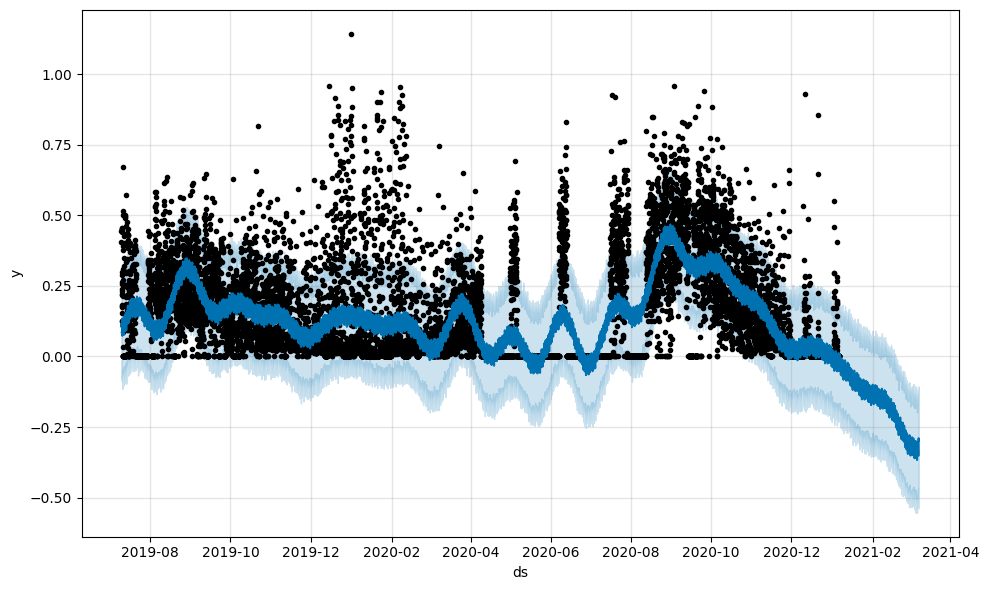

In [11]:
model.plot(forecast)
plt.show()

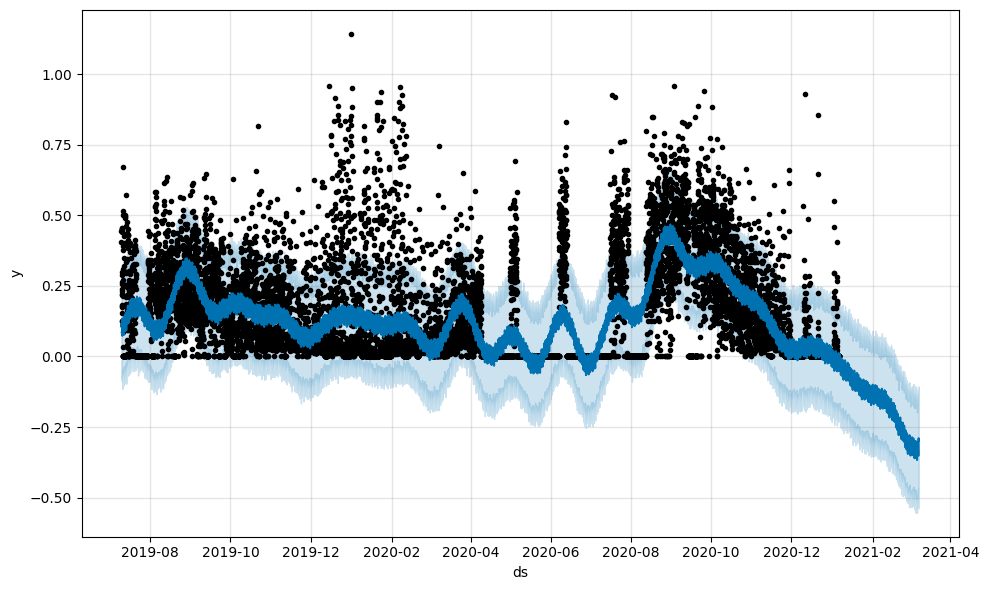

In [16]:
fig = model.plot(forecast)

plt.savefig("../reports/figures/prophet_forecast.png")

plt.show()

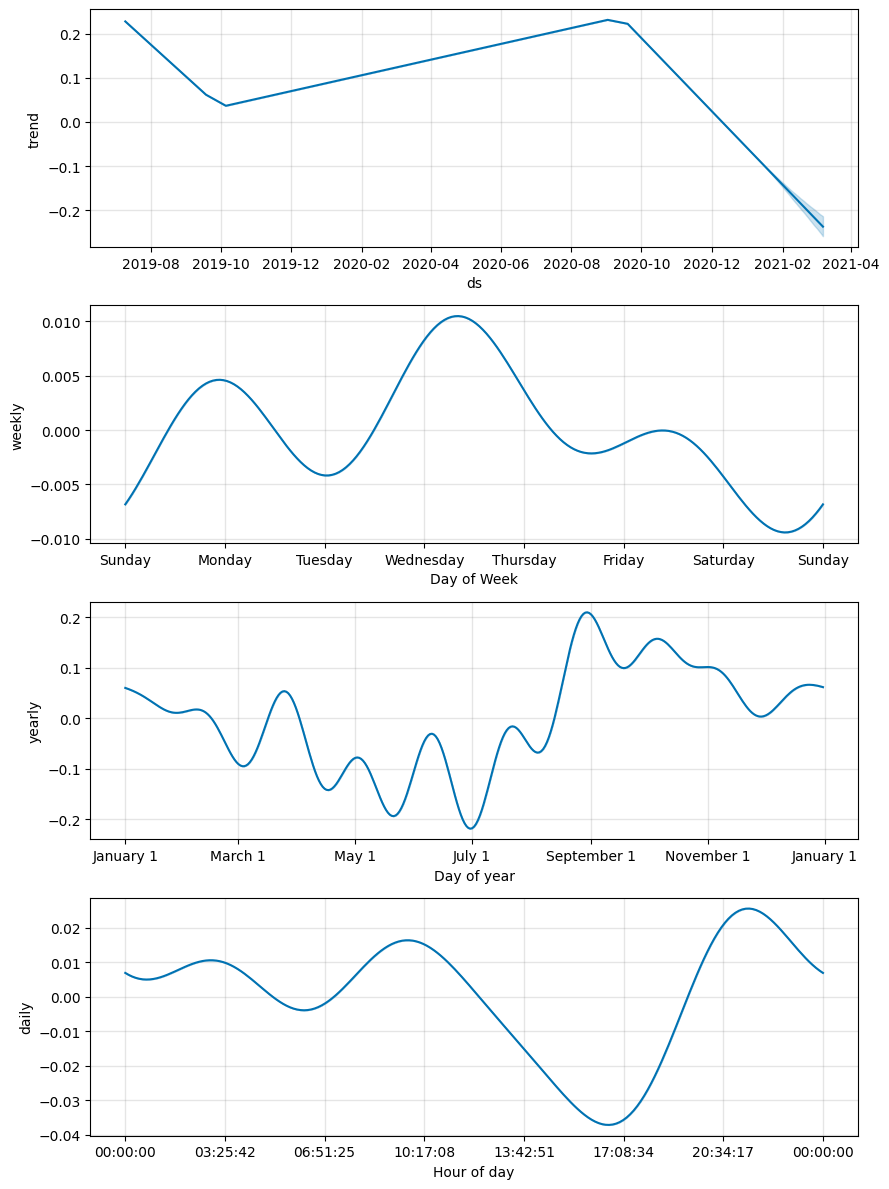

In [12]:
model.plot_components(
    forecast
)

plt.show()

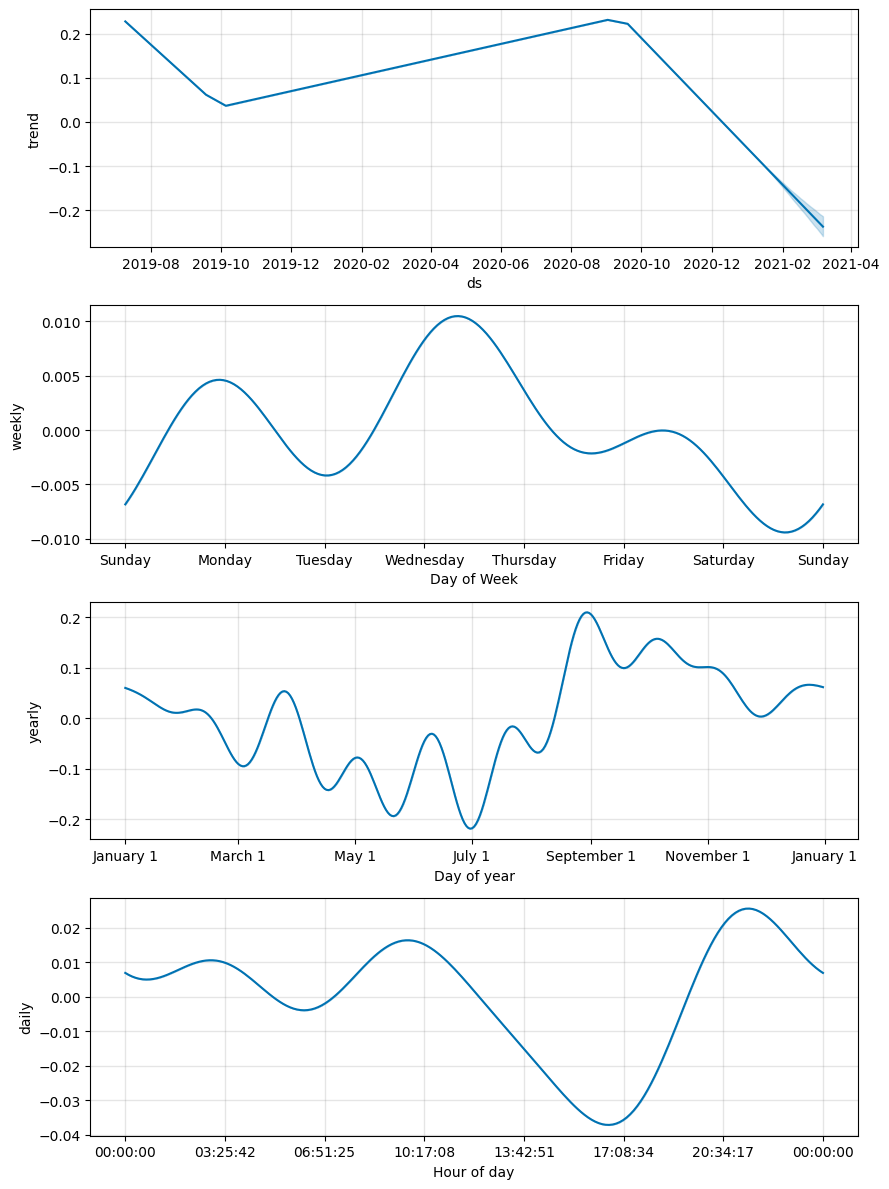

In [17]:
fig = model.plot_components(forecast)

plt.savefig("../reports/figures/prophet_components.png")

plt.show()

In [13]:
predictions = forecast[
    "yhat"
].tail(len(test))

mae = mean_absolute_error(
    test["y"],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        predictions
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.21811975111637605
RMSE: 0.26845284324727864


In [14]:
prophet_df.head()
prophet_df.shape

(14568, 2)

In [15]:
results = pd.DataFrame({
    "Model": ["Prophet"],
    "MAE": [0.2181],
    "RMSE": [0.2685]
})

results

,Model,MAE,RMSE
0,Prophet,0.2181,0.2685
